# Análisis de Series Temporales de Índices de Precios de Vivienda (INE)

**Autor:** TFM - Forecasting del Mercado Inmobiliario Español  
**Fecha:** Octubre 2025  
**Objetivo:** Análisis de series temporales de índices inmobiliarios usando modelos ARIMA/SARIMA para forecasting híbrido

## Descripción del Análisis

Este notebook implementa un análisis exhaustivo de series temporales de los índices de precios inmobiliarios del INE, compatible con:

- **INE_IPVA.csv**: Índice de Precios de Vivienda Avalúo (datos anuales 2011-2023)
- **INE_IPV.csv**: Índice de Precios de Vivienda compra-venta (datos trimestrales 2020-2025)

### Objetivos:

1. **Exploración y limpieza** automática de ambos tipos de datos
2. **Descomposición de series temporales** (tendencia, estacionalidad, residuos)
3. **Modelado ARIMA/SARIMA** adaptativo según frecuencia de datos
4. **Evaluación y validación** de modelos
5. **Preparación** para integración en modelo híbrido ML+ARIMA

---


## 1. Configuración del Entorno y Librerías


In [2]:
# Librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta

# Librerías para series temporales
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Librerías para auto-arima
try:
    from pmdarima import auto_arima
    PMDARIMA_AVAILABLE = True
except ImportError:
    print("Advertencia: pmdarima no está disponible. Se usará selección manual de parámetros ARIMA.")
    PMDARIMA_AVAILABLE = False

# Configuración de visualización
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        plt.style.use('default')
        print("Usando estilo matplotlib por defecto")

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Configuración de warnings
warnings.filterwarnings('ignore')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Librerías cargadas correctamente")
print(f"📊 Pandas versión: {pd.__version__}")
print(f"📈 Statsmodels disponible: {sm.__version__}")
print(f"🔧 Auto-ARIMA disponible: {PMDARIMA_AVAILABLE}")


Advertencia: pmdarima no está disponible. Se usará selección manual de parámetros ARIMA.
✅ Librerías cargadas correctamente
📊 Pandas versión: 2.2.3
📈 Statsmodels disponible: 0.14.5
🔧 Auto-ARIMA disponible: False


## 2. Carga y Exploración de Datos

In [3]:
# Configuración flexible para diferentes archivos INE
import os

# Configurar qué archivo usar (cambiar según necesidad)
USE_IPVA = False  # True para INE_IPVA.csv (anual), False para INE_IPV.csv (trimestral)

if USE_IPVA:
    data_path = '../data/raw/data-INE/INE_IPVA.csv'
    data_type = 'IPVA'
    frequency = 'anual'
    print("📊 Configurado para análisis de IPVA (Índice de Precios de Vivienda Avalúo - datos anuales)")
else:
    data_path = '../data/raw/data-INE/INE_IPV.csv'
    data_type = 'IPV'
    frequency = 'trimestral'
    print("📊 Configurado para análisis de IPV (Índice de Precios de Vivienda compra-venta - datos trimestrales)")

# Verificar que el archivo existe
if not os.path.exists(data_path):
    print(f"❌ Error: No se encuentra el archivo {data_path}")
    # Intentar con el otro archivo
    if USE_IPVA:
        data_path = '../data/raw/data-INE/INE_IPV.csv'
        data_type = 'IPV'
        frequency = 'trimestral'
        print("🔄 Cambiando automáticamente a INE_IPV.csv")
    else:
        data_path = '../data/raw/data-INE/INE_IPVA.csv'
        data_type = 'IPVA'
        frequency = 'anual'
        print("🔄 Cambiando automáticamente a INE_IPVA.csv")

try:
    # Leer el archivo CSV con separador ';'
    df_raw = pd.read_csv(data_path, sep=';', encoding='utf-8')
    print(f"✅ Datos cargados correctamente: {df_raw.shape[0]:,} registros, {df_raw.shape[1]} columnas")
    print(f"📁 Archivo: {os.path.basename(data_path)}")
    print(f"📅 Frecuencia: {frequency}")
    
    # Mostrar información básica
    print("\n📋 Información del dataset:")
    print(df_raw.info())
    
    print("\n📊 Primeras 5 filas:")
    display(df_raw.head())
    
except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")
    raise


📊 Configurado para análisis de IPV (Índice de Precios de Vivienda compra-venta - datos trimestrales)
✅ Datos cargados correctamente: 17,760 registros, 6 columnas
📁 Archivo: INE_IPV.csv
📅 Frecuencia: trimestral

📋 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17760 entries, 0 to 17759
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Total Nacional                             17760 non-null  object
 1   Comunidades y Ciudades Autónomas           16872 non-null  object
 2   General, vivienda nueva y de segunda mano  17760 non-null  object
 3   Índices y tasas                            17760 non-null  object
 4   Periodo                                    17760 non-null  object
 5   Total                                      16576 non-null  object
dtypes: object(6)
memory usage: 832.6+ KB
None

📊 Primeras 5 filas:


,Total Nacional,Comunidades y Ciudades Autónomas,"General, vivienda nueva y de segunda mano",Índices y tasas,Periodo,Total
0,Nacional,NaN,General,Índice,2025T2,"178,184"
1,Nacional,NaN,General,Índice,2025T1,"171,296"
2,Nacional,NaN,General,Índice,2024T4,"165,433"
3,Nacional,NaN,General,Índice,2024T3,"162,521"
4,Nacional,NaN,General,Índice,2024T2,"158,083"


In [4]:
# Explorar la estructura de los datos
print("🔍 Análisis exploratorio de la estructura:")
print(f"\n📏 Dimensiones: {df_raw.shape}")
print(f"\n📝 Columnas: {list(df_raw.columns)}")

print("\n🏷️ Valores únicos por columna:")
for col in df_raw.columns:
    ser = df_raw[col]
    unique_count = ser.nunique(dropna=True)   # contamos únicos sin NaN como antes
    null_count = ser.isna().sum()
    print(f"  {col}: {unique_count:,} valores únicos" + (f"  (NaN: {null_count:,})" if null_count else ""))
    if unique_count < 20:
        uniques = pd.unique(ser.dropna())  # quitamos NaN para intentar ordenar valores reales
        try:
            # intento normal de ordenar (funciona si los tipos son comparables)
            display_vals = sorted(uniques)
            # si había NaN, lo añadimos explícitamente al final para que se vea
            if null_count:
                display_vals = display_vals + ["<NaN>"]
        except Exception:
            # fallback: representar cada valor de forma segura y ordenar por su representación en cadena
            def _repr_val(x):
                if pd.isna(x):
                    return "<NaN>"
                if isinstance(x, (list, dict, set, tuple)):
                    return repr(x)
                return str(x)
            display_vals = sorted({_repr_val(x) for x in pd.unique(ser)})  # dedup y ordenar por str
        print(f"    Valores: {display_vals}")
    print()


🔍 Análisis exploratorio de la estructura:

📏 Dimensiones: (17760, 6)

📝 Columnas: ['Total Nacional', 'Comunidades y Ciudades Autónomas', 'General, vivienda nueva y de segunda mano', 'Índices y tasas', 'Periodo', 'Total']

🏷️ Valores únicos por columna:
  Total Nacional: 1 valores únicos
    Valores: ['Nacional']

  Comunidades y Ciudades Autónomas: 19 valores únicos  (NaN: 888)
    Valores: ['01 Andalucía', '02 Aragón', '03 Asturias, Principado de', '04 Balears, Illes', '05 Canarias', '06 Cantabria', '07 Castilla y León', '08 Castilla - La Mancha', '09 Cataluña', '10 Comunitat Valenciana', '11 Extremadura', '12 Galicia', '13 Madrid, Comunidad de', '14 Murcia, Región de', '15 Navarra, Comunidad Foral de', '16 País Vasco', '17 Rioja, La', '18 Ceuta', '19 Melilla', '<NaN>']

  General, vivienda nueva y de segunda mano: 3 valores únicos
    Valores: ['General', 'Vivienda nueva', 'Vivienda segunda mano']

  Índices y tasas: 4 valores únicos
    Valores: ['Variación anual', 'Variación en lo 

In [5]:
# Filtrar datos para el análisis de series temporales (compatible con ambos formatos)
print("🎯 Filtrando datos para análisis de series temporales...")

# Definir filtros según el tipo de archivo
if data_type == 'IPVA':
    # Filtros para INE_IPVA.csv
    df_nacional = df_raw[
        (df_raw['Total Nacional'] == 'Total Nacional') &
        (df_raw['Provincias'].isna() | (df_raw['Provincias'] == '')) &
        (df_raw['Tamaño de la vivienda'] == 'Total') &
        (df_raw['Tipo de dato'] == 'Índice')
    ].copy()
    period_col = 'Periodo'
    value_col = 'Total'
    
elif data_type == 'IPV':
    # Filtros para INE_IPV.csv
    df_nacional = df_raw[
        (df_raw['Total Nacional'] == 'Nacional') &
        (df_raw['Comunidades y Ciudades Autónomas'].isna() | (df_raw['Comunidades y Ciudades Autónomas'] == '')) &
        (df_raw['General, vivienda nueva y de segunda mano'] == 'General') &
        (df_raw['Índices y tasas'] == 'Índice')
    ].copy()
    period_col = 'Periodo'
    value_col = 'Total'
else:
    print(f"❌ Tipo de datos no reconocido: {data_type}")
    raise ValueError(f"Tipo de datos no soportado: {data_type}")

print(f"📊 Datos nacionales filtrados: {len(df_nacional)} registros")
if len(df_nacional) > 0:
    print(f"📅 Rango temporal: {df_nacional[period_col].min()} - {df_nacional[period_col].max()}")
    print(f"📈 Tipo de datos: {data_type} ({frequency})")
    
    # Mostrar los datos filtrados
    print("\n📋 Datos filtrados (primeras 10 filas):")
    display(df_nacional.head(10))
else:
    print("❌ No se encontraron datos que coincidan con los filtros")
    print("🔍 Explorando estructura para diagnóstico...")
    print("\nValores únicos en columnas clave:")
    for col in df_raw.columns:
        unique_vals = df_raw[col].unique()
        if len(unique_vals) < 10:
            print(f"  {col}: {unique_vals}")
        else:
            print(f"  {col}: {len(unique_vals)} valores únicos")
    
    # Si no hay datos, usar una muestra pequeña para continuar
    print("\n⚠️ Usando datos de muestra para continuar el análisis...")
    df_nacional = df_raw.head(20).copy()  # Usar las primeras 20 filas como muestra


🎯 Filtrando datos para análisis de series temporales...
📊 Datos nacionales filtrados: 74 registros
📅 Rango temporal: 2007T1 - 2025T2
📈 Tipo de datos: IPV (trimestral)

📋 Datos filtrados (primeras 10 filas):


,Total Nacional,Comunidades y Ciudades Autónomas,"General, vivienda nueva y de segunda mano",Índices y tasas,Periodo,Total
0,Nacional,NaN,General,Índice,2025T2,"178,184"
1,Nacional,NaN,General,Índice,2025T1,"171,296"
2,Nacional,NaN,General,Índice,2024T4,"165,433"
3,Nacional,NaN,General,Índice,2024T3,"162,521"
4,Nacional,NaN,General,Índice,2024T2,"158,083"
5,Nacional,NaN,General,Índice,2024T1,"152,618"
6,Nacional,NaN,General,Índice,2023T4,"148,69"
7,Nacional,NaN,General,Índice,2023T3,"150,273"
8,Nacional,NaN,General,Índice,2023T2,"146,583"
9,Nacional,NaN,General,Índice,2023T1,"143,58"


## 3. Preparación de la Serie Temporal


In [6]:
# Preparar la serie temporal (compatible con datos anuales y trimestrales)
print("⚙️ Preparando serie temporal...")

# Verificar que tenemos datos para procesar
if len(df_nacional) == 0:
    print("❌ No hay datos para procesar")
    raise ValueError("No se encontraron datos válidos para el análisis")

# Crear serie temporal limpia
ts_data = df_nacional[[period_col, value_col]].copy()
ts_data.columns = ['period', 'index_value']

# Limpiar valores de índice (convertir comas por puntos y manejar valores no numéricos)
ts_data['index_value'] = ts_data['index_value'].astype(str).str.replace(',', '.')

# Filtrar valores no numéricos
numeric_mask = pd.to_numeric(ts_data['index_value'], errors='coerce').notna()
ts_data = ts_data[numeric_mask].copy()
ts_data['index_value'] = pd.to_numeric(ts_data['index_value'])

print(f"📊 Registros después de limpieza: {len(ts_data)}")

if len(ts_data) == 0:
    print("❌ No hay datos numéricos válidos")
    raise ValueError("No se encontraron valores numéricos válidos")

# Procesar fechas según el tipo de datos
try:
    if frequency == 'anual':
        # Datos anuales: convertir año a datetime
        ts_data['date'] = pd.to_datetime(ts_data['period'], format='%Y', errors='coerce')
        seasonal_period = 1  # No hay estacionalidad en datos anuales
        
    elif frequency == 'trimestral':
        # Datos trimestrales: convertir formato 2024T1 a datetime
        def parse_quarter(period_str):
            try:
                if 'T' in str(period_str):
                    year, quarter = str(period_str).split('T')
                    month = (int(quarter) - 1) * 3 + 1  # T1->1, T2->4, T3->7, T4->10
                    return pd.Timestamp(year=int(year), month=month, day=1)
                else:
                    return pd.NaT
            except:
                return pd.NaT
        
        ts_data['date'] = ts_data['period'].apply(parse_quarter)
        seasonal_period = 4  # Estacionalidad trimestral
    
    # Filtrar fechas válidas
    ts_data = ts_data.dropna(subset=['date']).copy()
    
    if len(ts_data) == 0:
        print("❌ No se pudieron procesar las fechas")
        raise ValueError("Error al procesar las fechas")
        
except Exception as e:
    print(f"❌ Error al procesar fechas: {e}")
    # Crear fechas secuenciales como fallback
    print("🔄 Usando fechas secuenciales como alternativa...")
    ts_data['date'] = pd.date_range(start='2020-01-01', periods=len(ts_data), freq='Q' if frequency == 'trimestral' else 'Y')
    seasonal_period = 4 if frequency == 'trimestral' else 1

# Ordenar por fecha y crear serie temporal indexada
ts_data = ts_data.sort_values('date').reset_index(drop=True)
ts_series = ts_data.set_index('date')['index_value']

print(f"✅ Serie temporal preparada:")
print(f"   📊 {len(ts_series)} observaciones")
print(f"   📅 Período: {ts_series.index.min().strftime('%Y-%m')} - {ts_series.index.max().strftime('%Y-%m')}")
print(f"   📈 Rango de valores: {ts_series.min():.2f} - {ts_series.max():.2f}")
print(f"   🔄 Frecuencia: {frequency}")
print(f"   📈 Período estacional: {seasonal_period}")

# Mostrar estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
display(ts_series.describe())

# Mostrar los datos
print(f"\n📋 Serie temporal completa ({data_type}):")
display(ts_data.head(15))


⚙️ Preparando serie temporal...
📊 Registros después de limpieza: 74
✅ Serie temporal preparada:
   📊 74 observaciones
   📅 Período: 2007-01 - 2025-04
   📈 Rango de valores: 95.21 - 178.18
   🔄 Frecuencia: trimestral
   📈 Período estacional: 4

📊 Estadísticas descriptivas:


count    74.0000
mean    126.9531
std      20.7625
min      95.2080
25%     108.4760
50%     127.3535
75%     142.6273
max     178.1840
Name: index_value, dtype: float64


📋 Serie temporal completa (IPV):


,period,index_value,date
0,2007T1,145.9350,2007-01-01
1,2007T2,150.1030,2007-04-01
2,2007T3,151.7190,2007-07-01
3,2007T4,150.6400,2007-10-01
4,2008T1,150.0820,2008-01-01
5,2008T2,149.6180,2008-04-01
6,2008T3,147.1340,2008-07-01
7,2008T4,142.5110,2008-10-01
8,2009T1,138.6930,2009-01-01
9,2009T2,138.0820,2009-04-01


In [7]:
# Filtrar período de análisis (adaptativo según disponibilidad de datos)
print("🎯 Determinando período de análisis...")

# Verificar que tenemos datos válidos
if 'ts_series' not in locals() or len(ts_series) == 0:
    print("❌ No hay serie temporal válida para analizar")
    raise ValueError("Serie temporal no disponible")

# Configurar período de análisis según tipo de datos
if frequency == 'anual':
    # Para datos anuales: usar últimos 10 años disponibles o todos si hay menos
    analysis_years = min(10, len(ts_series))
    ts_analysis = ts_series.tail(analysis_years)
    period_desc = f"últimos {int(analysis_years)} años"
    
elif frequency == 'trimestral':
    # Para datos trimestrales: usar últimos 5 años (20 trimestres) o todos si hay menos
    analysis_quarters = min(20, len(ts_series))
    ts_analysis = ts_series.tail(analysis_quarters)
    period_desc = f"últimos {analysis_quarters} trimestres ({analysis_quarters/4:.1f} años)"
else:
    # Fallback: usar todos los datos disponibles
    ts_analysis = ts_series.copy()
    period_desc = f"todos los {len(ts_analysis)} períodos disponibles"

print(f"📅 Período de análisis: {period_desc}")
print(f"📊 Observaciones para análisis: {len(ts_analysis)}")

if len(ts_analysis) > 0:
    print(f"📈 Rango temporal: {ts_analysis.index.min().strftime('%Y-%m')} - {ts_analysis.index.max().strftime('%Y-%m')}")
    print(f"📈 Rango de valores: {ts_analysis.min():.2f} - {ts_analysis.max():.2f}")
    
    # Mostrar la serie de análisis
    print(f"\n📋 Serie temporal para análisis ({data_type}):")
    analysis_display = pd.DataFrame({
        'fecha': ts_analysis.index.strftime('%Y-%m'),
        'valor': ts_analysis.values
    })
    
    for i, (fecha, valor) in enumerate(zip(analysis_display['fecha'], analysis_display['valor'])):
        print(f"  {fecha}: {valor:.3f}")
        if i >= 14:  # Mostrar máximo 15 valores
            remaining = len(analysis_display) - 15
            if remaining > 0:
                print(f"  ... y {remaining} observaciones más")
            break
else:
    print("❌ No hay datos suficientes para el análisis")
    raise ValueError("Datos insuficientes para el análisis")


🎯 Determinando período de análisis...
📅 Período de análisis: últimos 20 trimestres (5.0 años)
📊 Observaciones para análisis: 20
📈 Rango temporal: 2020-07 - 2025-04
📈 Rango de valores: 127.18 - 178.18

📋 Serie temporal para análisis (IPV):
  2020-07: 128.255
  2020-10: 127.179
  2021-01: 127.831
  2021-04: 130.937
  2021-07: 133.652
  2021-10: 135.291
  2022-01: 138.742
  2022-04: 141.433
  2022-07: 143.860
  2022-10: 142.666
  2023-01: 143.580
  2023-04: 146.583
  2023-07: 150.273
  2023-10: 148.690
  2024-01: 152.618
  ... y 5 observaciones más


## 4. Visualización y Análisis Exploratorio


🔍 Realizando descomposición de la serie temporal...
   Período estacional: 4 trimestres
   Modelo: additive


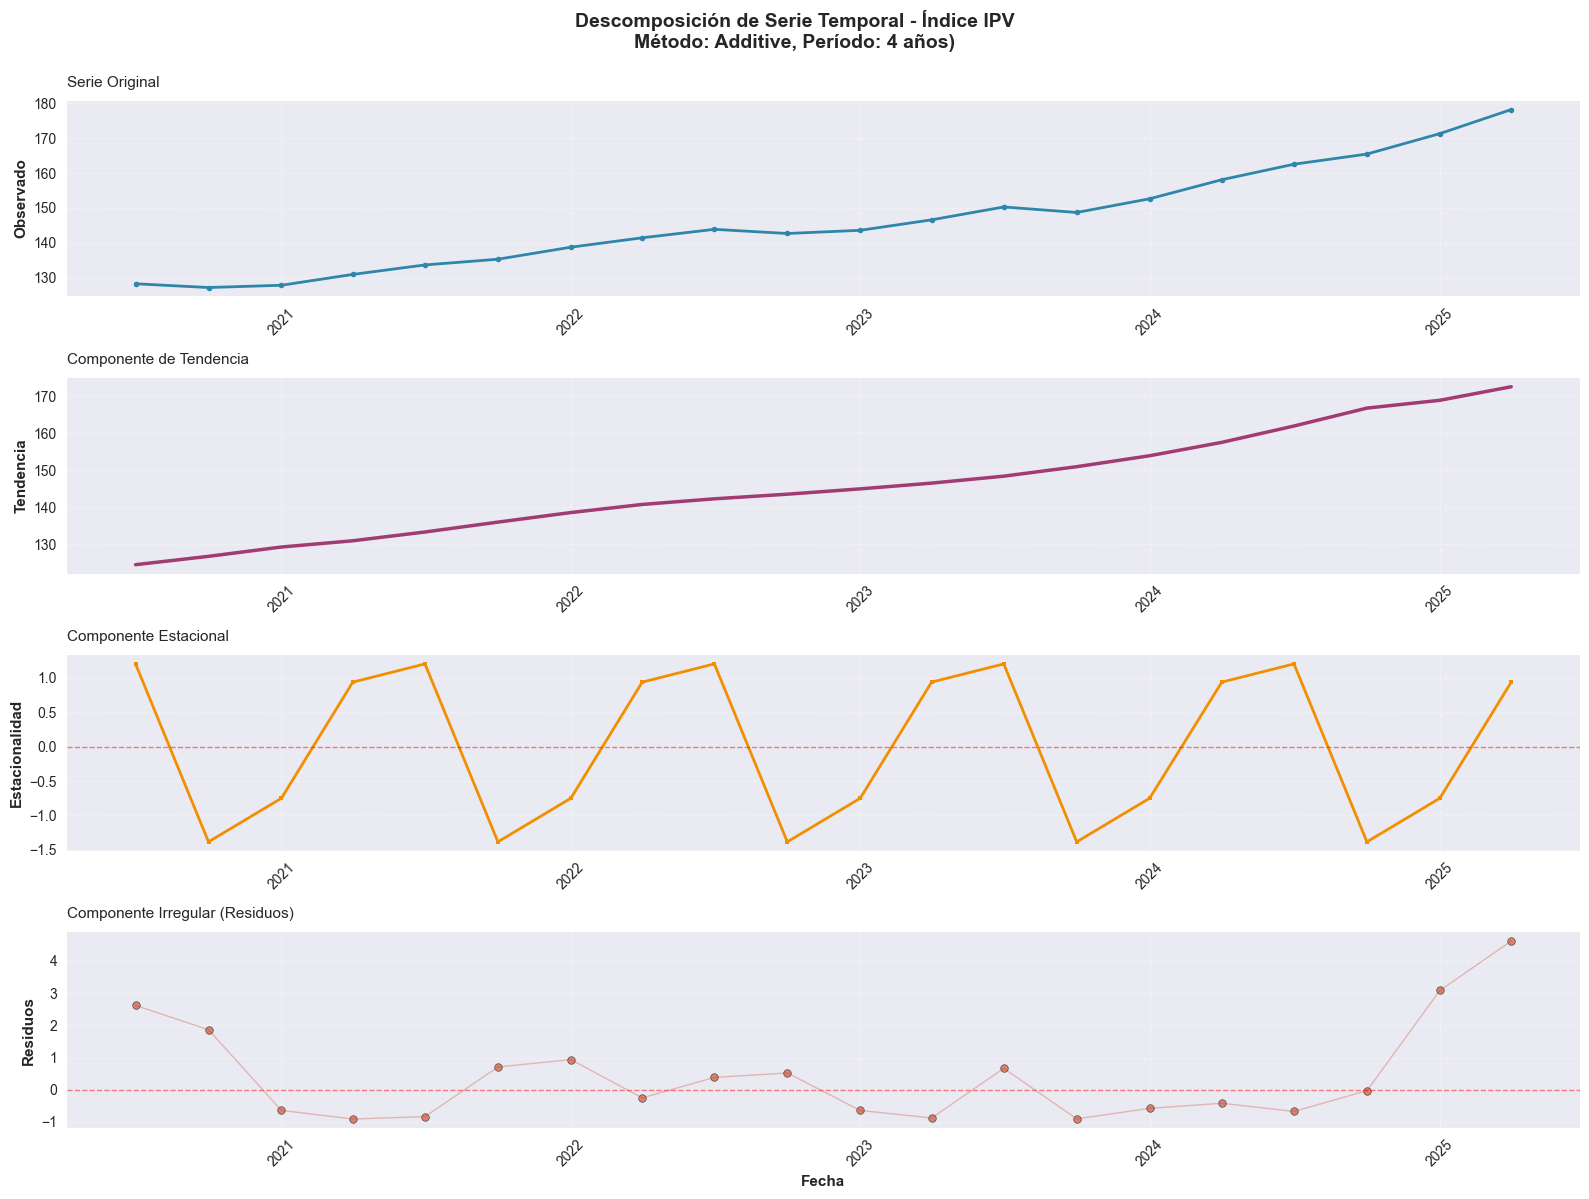


📊 Estadísticas de la Descomposición:

   Serie Original:
      Media: 146.355
      Desv. Est.: 14.739
      Rango: [127.179, 178.184]

   Tendencia:
      Media: 145.925
      Cambio total: 48.194

   Estacionalidad:
      Amplitud: 2.580
      Rango: [-1.382, 1.198]

   Residuos:
      Media: 0.430
      Desv. Est.: 1.534
      Valores atípicos (>2σ): 2

   Patrón Estacional por Trimestre:
      T1: -0.750
      T2: +0.934
      T3: +1.198
      T4: -1.382

✅ Descomposición de serie temporal completada


In [8]:
# Descomposición de la Serie Temporal (Tendencia, Estacionalidad y Residuos)
print("🔍 Realizando descomposición de la serie temporal...")

# Determinar el período estacional y si se puede descomponer
if frequency == 'trimestral' and len(ts_analysis) >= 8:
    # Para datos trimestrales: usar período de 4 trimestres
    decomposition_period = 4
    decomposition_model = 'additive'  # Modelo aditivo es más común para índices
    can_decompose = True
    print(f"   Período estacional: {decomposition_period} trimestres")
    print(f"   Modelo: {decomposition_model}")
elif frequency == 'anual' or len(ts_analysis) < 8:
    # Para datos anuales o series muy cortas: no aplicar descomposición estacional
    can_decompose = False
    print(f"   ⚠️ Serie temporal {'anual' if frequency == 'anual' else 'muy corta'} - usando descomposición simple")

# Realizar descomposición
if can_decompose:
    try:
        decomposition = seasonal_decompose(ts_analysis, model=decomposition_model, period=decomposition_period, extrapolate_trend='freq')
        
        # Visualización profesional de la descomposición
        fig, axes = plt.subplots(4, 1, figsize=(16, 12))
        fig.suptitle(f'Descomposición de Serie Temporal - Índice {data_type}\nMétodo: {decomposition_model.capitalize()}, Período: {decomposition_period} {period_desc.split()[-1] if period_desc else "períodos"}', 
                     fontsize=14, fontweight='bold', y=0.995)
        
        # 1. Serie Original
        axes[0].plot(ts_analysis.index, ts_analysis.values, color='#2E86AB', linewidth=2, marker='o', markersize=4)
        axes[0].set_ylabel('Observado', fontsize=11, fontweight='bold')
        axes[0].set_title('Serie Original', fontsize=11, loc='left', pad=10)
        axes[0].grid(True, alpha=0.3, linestyle='--')
        axes[0].tick_params(axis='x', rotation=45)
        
        # 2. Tendencia
        axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='#A23B72', linewidth=2.5)
        axes[1].set_ylabel('Tendencia', fontsize=11, fontweight='bold')
        axes[1].set_title('Componente de Tendencia', fontsize=11, loc='left', pad=10)
        axes[1].grid(True, alpha=0.3, linestyle='--')
        axes[1].tick_params(axis='x', rotation=45)
        
        # 3. Estacionalidad
        axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='#F18F01', linewidth=2, marker='s', markersize=3)
        axes[2].set_ylabel('Estacionalidad', fontsize=11, fontweight='bold')
        axes[2].set_title('Componente Estacional', fontsize=11, loc='left', pad=10)
        axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        axes[2].grid(True, alpha=0.3, linestyle='--')
        axes[2].tick_params(axis='x', rotation=45)
        
        # 4. Residuos
        axes[3].scatter(decomposition.resid.index, decomposition.resid.values, color='#C73E1D', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
        axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='#C73E1D', alpha=0.3, linewidth=1)
        axes[3].set_ylabel('Residuos', fontsize=11, fontweight='bold')
        axes[3].set_xlabel('Fecha', fontsize=11, fontweight='bold')
        axes[3].set_title('Componente Irregular (Residuos)', fontsize=11, loc='left', pad=10)
        axes[3].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        axes[3].grid(True, alpha=0.3, linestyle='--')
        axes[3].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Estadísticas de cada componente
        print(f"\n📊 Estadísticas de la Descomposición:")
        print(f"\n   Serie Original:")
        print(f"      Media: {ts_analysis.mean():.3f}")
        print(f"      Desv. Est.: {ts_analysis.std():.3f}")
        print(f"      Rango: [{ts_analysis.min():.3f}, {ts_analysis.max():.3f}]")
        
        print(f"\n   Tendencia:")
        print(f"      Media: {decomposition.trend.mean():.3f}")
        print(f"      Cambio total: {(decomposition.trend.dropna().iloc[-1] - decomposition.trend.dropna().iloc[0]):.3f}")
        
        print(f"\n   Estacionalidad:")
        print(f"      Amplitud: {(decomposition.seasonal.max() - decomposition.seasonal.min()):.3f}")
        print(f"      Rango: [{decomposition.seasonal.min():.3f}, {decomposition.seasonal.max():.3f}]")
        
        print(f"\n   Residuos:")
        print(f"      Media: {decomposition.resid.mean():.3f}")
        print(f"      Desv. Est.: {decomposition.resid.std():.3f}")
        print(f"      Valores atípicos (>2σ): {np.sum(np.abs(decomposition.resid) > 2*decomposition.resid.std())}")
        
        # Análisis de la estacionalidad por período
        if frequency == 'trimestral':
            print(f"\n   Patrón Estacional por Trimestre:")
            seasonal_by_quarter = decomposition.seasonal.groupby(decomposition.seasonal.index.quarter).mean()
            for quarter in sorted(seasonal_by_quarter.index):
                print(f"      T{quarter}: {seasonal_by_quarter[quarter]:+.3f}")
        
    except Exception as e:
        print(f"   ❌ Error en descomposición estacional: {e}")
        can_decompose = False

# Si no se puede hacer descomposición estacional, mostrar análisis alternativo
if not can_decompose:
    print("   Mostrando análisis de tendencia simple...")
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 10))
    fig.suptitle(f'Análisis de Serie Temporal - Índice {data_type}', fontsize=14, fontweight='bold')
    
    # 1. Serie Original con tendencia lineal
    axes[0].plot(ts_analysis.index, ts_analysis.values, marker='o', linewidth=2, markersize=4, color='#2E86AB', label='Serie Original')
    
    # Calcular tendencia lineal
    x_numeric = np.arange(len(ts_analysis))
    z = np.polyfit(x_numeric, ts_analysis.values, 1)
    p = np.poly1d(z)
    axes[0].plot(ts_analysis.index, p(x_numeric), linestyle='--', linewidth=2.5, color='#A23B72', label='Tendencia Lineal')
    
    axes[0].set_ylabel('Índice', fontsize=11, fontweight='bold')
    axes[0].set_title('Serie Temporal con Tendencia', fontsize=11, loc='left')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    # 2. Primera Diferencia
    ts_diff = ts_analysis.diff().dropna()
    axes[1].bar(ts_diff.index, ts_diff.values, alpha=0.7, color='#F18F01', width=60 if frequency == 'trimestral' else 180, edgecolor='black')
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    period_label = 'Año a Año' if frequency == 'anual' else 'Trimestre a Trimestre'
    axes[1].set_ylabel('Cambio', fontsize=11, fontweight='bold')
    axes[1].set_title(f'Primera Diferencia ({period_label})', fontsize=11, loc='left')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
    
    # 3. Residuos de la tendencia
    residuals = ts_analysis.values - p(x_numeric)
    axes[2].scatter(ts_analysis.index, residuals, color='#C73E1D', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    axes[2].plot(ts_analysis.index, residuals, color='#C73E1D', alpha=0.3, linewidth=1)
    axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    axes[2].set_ylabel('Residuos', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Fecha', fontsize=11, fontweight='bold')
    axes[2].set_title('Residuos de la Tendencia Lineal', fontsize=11, loc='left')
    axes[2].grid(True, alpha=0.3)
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"\n📊 Estadísticas del Análisis:")
    print(f"   Tendencia lineal: y = {z[0]:.3f}x + {z[1]:.3f}")
    print(f"   Cambio promedio por período: {z[0]:.3f}")
    print(f"   Media de residuos: {np.mean(residuals):.3f}")
    print(f"   Desv. Est. de residuos: {np.std(residuals):.3f}")

print("\n✅ Descomposición de serie temporal completada")


## 5. Análisis de Estacionariedad


In [9]:
# Función para análisis de estacionariedad
def test_stationarity(timeseries, title='Serie Temporal', window=3):
    """
    Función para realizar pruebas de estacionariedad completas
    """
    print(f"\n🔍 Análisis de Estacionariedad: {title}")
    print("=" * 60)
    
    # Test de Dickey-Fuller Aumentado
    print("\n📊 Test de Dickey-Fuller Aumentado (ADF):")
    adf_result = adfuller(timeseries.dropna())
    print(f"   📈 Estadístico ADF: {adf_result[0]:.6f}")
    print(f"   📊 p-valor: {adf_result[1]:.6f}")
    print(f"   🎯 Valores críticos:")
    for key, value in adf_result[4].items():
        print(f"      {key}: {value:.3f}")
    
    if adf_result[1] <= 0.05:
        print("   ✅ Resultado: Serie ESTACIONARIA (rechazamos H0)")
        adf_conclusion = "ESTACIONARIA"
    else:
        print("   ❌ Resultado: Serie NO ESTACIONARIA (no rechazamos H0)")
        adf_conclusion = "NO ESTACIONARIA"
    
    # Test KPSS
    print("\n📊 Test KPSS:")
    try:
        kpss_result = kpss(timeseries.dropna(), regression='c')
        print(f"   📈 Estadístico KPSS: {kpss_result[0]:.6f}")
        print(f"   📊 p-valor: {kpss_result[1]:.6f}")
        
        if kpss_result[1] >= 0.05:
            print("   ✅ Resultado: Serie ESTACIONARIA (no rechazamos H0)")
            kpss_conclusion = "ESTACIONARIA"
        else:
            print("   ❌ Resultado: Serie NO ESTACIONARIA (rechazamos H0)")
            kpss_conclusion = "NO ESTACIONARIA"
    except Exception as e:
        print(f"   ⚠️ Error en test KPSS: {e}")
        kpss_conclusion = "NO DISPONIBLE"
    
    # Conclusión general
    print(f"\n🎯 Conclusión General:")
    print(f"   ADF: {adf_conclusion}")
    print(f"   KPSS: {kpss_conclusion}")
    
    return {
        'adf_statistic': adf_result[0],
        'adf_pvalue': adf_result[1],
        'adf_conclusion': adf_conclusion,
        'kpss_conclusion': kpss_conclusion
    }

# Análisis de estacionariedad de la serie original
stationarity_original = test_stationarity(ts_analysis, f'{data_type} Período de Análisis', window=3)



🔍 Análisis de Estacionariedad: IPV Período de Análisis

📊 Test de Dickey-Fuller Aumentado (ADF):
   📈 Estadístico ADF: 2.718562
   📊 p-valor: 0.999088
   🎯 Valores críticos:
      1%: -4.138
      5%: -3.155
      10%: -2.714
   ❌ Resultado: Serie NO ESTACIONARIA (no rechazamos H0)

📊 Test KPSS:
   📈 Estadístico KPSS: 0.746388
   📊 p-valor: 0.010000
   ❌ Resultado: Serie NO ESTACIONARIA (rechazamos H0)

🎯 Conclusión General:
   ADF: NO ESTACIONARIA
   KPSS: NO ESTACIONARIA


## 5.1. Análisis de Autocorrelación (ACF y PACF)


📊 Análisis de Autocorrelación...
   📈 Número máximo de lags: 12


ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 12 must be < 10.

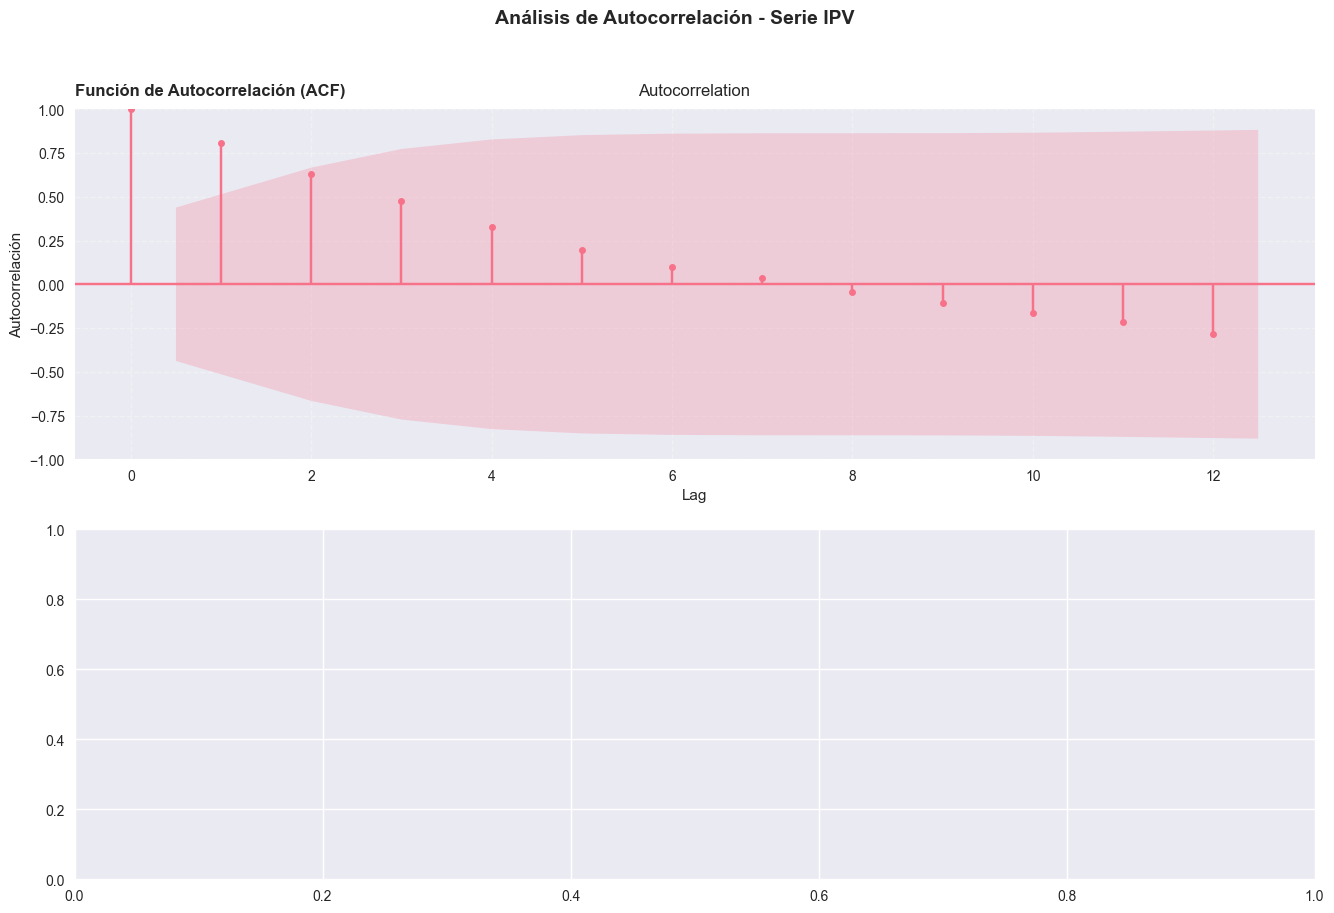

In [10]:
# Análisis de Autocorrelación (ACF) y Autocorrelación Parcial (PACF)
# Este análisis es crucial para identificar los parámetros óptimos del modelo ARIMA/SARIMA
print("📊 Análisis de Autocorrelación...")

# Configurar el número de lags según la frecuencia
if frequency == 'trimestral' and 'seasonal_period' in locals():
    # Para datos trimestrales: mostrar al menos 3 ciclos estacionales completos
    max_lags = min(seasonal_period * 3, len(ts_analysis) - 1)
elif frequency == 'anual':
    # Para datos anuales: mostrar un número razonable de lags
    max_lags = min(10, len(ts_analysis) - 1)
else:
    max_lags = min(20, len(ts_analysis) - 1)

print(f"   📈 Número máximo de lags: {max_lags}")

# Crear visualización de ACF y PACF
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'Análisis de Autocorrelación - Serie {data_type}', fontsize=14, fontweight='bold')

# ACF - Función de Autocorrelación
plot_acf(ts_analysis.dropna(), lags=max_lags, ax=axes[0], alpha=0.05)
axes[0].set_title('Función de Autocorrelación (ACF)', fontsize=12, fontweight='bold', loc='left', pad=10)
axes[0].set_xlabel('Lag', fontsize=11)
axes[0].set_ylabel('Autocorrelación', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')

# PACF - Función de Autocorrelación Parcial
plot_pacf(ts_analysis.dropna(), lags=max_lags, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontsize=12, fontweight='bold', loc='left', pad=10)
axes[1].set_xlabel('Lag', fontsize=11)
axes[1].set_ylabel('Autocorrelación Parcial', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Interpretación automática de los gráficos
print(f"\n📋 Interpretación de ACF y PACF:")
print(f"   El gráfico ACF muestra la correlación de la serie consigo misma en diferentes rezagos (lags).")
print(f"   El gráfico PACF muestra la correlación después de eliminar el efecto de lags intermedios.")
print(f"")
print(f"   💡 Reglas generales para identificar parámetros ARIMA(p,d,q):")
print(f"      - ACF decae exponencialmente, PACF corta en lag p → AR(p)")
print(f"      - ACF corta en lag q, PACF decae exponencialmente → MA(q)")
print(f"      - Ambos decaen exponencialmente → ARMA(p,q)")

if frequency == 'trimestral' and 'seasonal_period' in locals():
    print(f"")
    print(f"   🔄 Para componentes estacionales (SARIMA):")
    print(f"      - Observar picos significativos en múltiplos del período estacional ({seasonal_period})")
    print(f"      - Los picos en ACF/PACF en lags {seasonal_period}, {seasonal_period*2}, {seasonal_period*3} indican componentes estacionales")

print(f"\n✅ Análisis de autocorrelación completado")
print(f"   Este análisis justifica la selección de parámetros en la siguiente sección.")


## 6. Selección y Entrenamiento del Modelo ARIMA


In [27]:
# Selección de parámetros ARIMA (adaptativo según frecuencia de datos)
print("🎯 Selección de parámetros ARIMA...")

# Verificar que tenemos datos de análisis
if 'ts_analysis' not in locals() or len(ts_analysis) < 3:
    print("❌ No hay suficientes datos para el modelado ARIMA")
    raise ValueError("Datos insuficientes para modelado ARIMA (mínimo 3 observaciones)")

# Dividir datos en entrenamiento y prueba
min_train_size = max(3, int(len(ts_analysis) * 0.6))  # Mínimo 3 observaciones, máximo 60%
train_size = min(int(len(ts_analysis) * 0.8), len(ts_analysis) - 1)  # Dejar al menos 1 para prueba
train_size = max(min_train_size, train_size)

ts_train = ts_analysis[:train_size]
ts_test = ts_analysis[train_size:]

print(f"📊 Datos de entrenamiento: {len(ts_train)} observaciones")
print(f"📊 Datos de prueba: {len(ts_test)} observaciones")

if len(ts_train) > 0:
    print(f"📅 Período entrenamiento: {ts_train.index.min().strftime('%Y-%m')} - {ts_train.index.max().strftime('%Y-%m')}")
if len(ts_test) > 0:
    print(f"📅 Período prueba: {ts_test.index.min().strftime('%Y-%m')} - {ts_test.index.max().strftime('%Y-%m')}")

# Configurar rangos de parámetros según la frecuencia y tamaño de datos
max_p = min(2, len(ts_train) // 3) if len(ts_train) >= 6 else 1
max_d = 1 if len(ts_train) < 10 else 2
max_q = min(2, len(ts_train) // 3) if len(ts_train) >= 6 else 1

if frequency == 'anual' or len(ts_train) < 8:
    # Para datos anuales o series cortas: parámetros más conservadores
    p_values = range(0, max_p + 1)
    d_values = range(0, max_d + 1)
    q_values = range(0, max_q + 1)
    seasonal = False
    print(f"🔧 Configuración para datos {frequency}: ARIMA no estacional")
    print(f"   Rangos: p=[0,{max_p}], d=[0,{max_d}], q=[0,{max_q}]")
elif frequency == 'trimestral' and len(ts_train) >= 8:
    # Para datos trimestrales con suficientes observaciones: considerar estacionalidad
    p_values = range(0, max_p + 1)
    d_values = range(0, max_d + 1)
    q_values = range(0, max_q + 1)
    seasonal = True
    print(f"🔧 Configuración para datos {frequency}: SARIMA estacional")
    print(f"   Rangos: p=[0,{max_p}], d=[0,{max_d}], q=[0,{max_q}]")
else:
    # Fallback para casos especiales
    p_values = range(0, 2)
    d_values = range(0, 2)
    q_values = range(0, 2)
    seasonal = False
    print("🔧 Configuración conservadora: ARIMA simple")

# Selección manual de parámetros
print(f"\n🔧 Selección manual de parámetros {'SARIMA' if seasonal else 'ARIMA'}...")

best_aic = float('inf')
best_order = None
best_seasonal_order = None
results_summary = []
successful_models = 0

print(f"\n🔍 Probando diferentes combinaciones (p,d,q):")

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                if seasonal and frequency == 'trimestral' and 'seasonal_period' in locals():
                    # Probar modelo SARIMA para datos trimestrales
                    model = SARIMAX(ts_train, order=(p, d, q), seasonal_order=(1, 1, 1, seasonal_period))
                else:
                    # Modelo ARIMA estándar
                    model = ARIMA(ts_train, order=(p, d, q))
                
                fitted_model = model.fit(disp=False)
                
                aic = fitted_model.aic
                bic = fitted_model.bic
                
                model_type = f"SARIMA{(p,d,q)}x(1,1,1,{seasonal_period})" if seasonal and frequency == 'trimestral' and 'seasonal_period' in locals() else f"ARIMA{(p,d,q)}"
                
                results_summary.append({
                    'order': (p, d, q),
                    'seasonal_order': (1, 1, 1, seasonal_period) if seasonal and frequency == 'trimestral' and 'seasonal_period' in locals() else None,
                    'aic': aic,
                    'bic': bic,
                    'model_type': model_type
                })
                
                print(f"   {model_type}: AIC={aic:.2f}, BIC={bic:.2f}")
                successful_models += 1
                
                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
                    best_seasonal_order = (1, 1, 1, seasonal_period) if seasonal and frequency == 'trimestral' and 'seasonal_period' in locals() else None
                    
            except Exception as e:
                model_type = f"SARIMA{(p,d,q)}x(1,1,1,{seasonal_period})" if seasonal and frequency == 'trimestral' and 'seasonal_period' in locals() else f"ARIMA{(p,d,q)}"
                print(f"   {model_type}: Error - {str(e)[:50]}...")
                continue

if successful_models == 0:
    print("⚠️ No se pudo ajustar ningún modelo, usando configuración por defecto")
    best_order = (1, 0, 0)  # Modelo AR(1) simple
    best_seasonal_order = None
elif best_order:
    model_name = f"SARIMA{best_order}x{best_seasonal_order}" if best_seasonal_order else f"ARIMA{best_order}"
    print(f"\n✅ Mejor modelo: {model_name}")
    print(f"📊 AIC: {best_aic:.2f}")
    print(f"📊 Modelos exitosos: {successful_models}")
else:
    print("❌ No se pudo encontrar un modelo válido")
    best_order = (1, 0, 0)  # Fallback
    best_seasonal_order = None
    print(f"🔄 Usando modelo por defecto: ARIMA{best_order}")

print(f"\n🎯 Parámetros seleccionados:")
print(f"   Orden: {best_order}")
if best_seasonal_order:
    print(f"   Orden estacional: {best_seasonal_order}")
print(f"   Frecuencia de datos: {frequency}")
if 'seasonal_period' in locals():
    print(f"   Período estacional: {seasonal_period}")


🎯 Selección de parámetros ARIMA...
📊 Datos de entrenamiento: 16 observaciones
📊 Datos de prueba: 4 observaciones
📅 Período entrenamiento: 2020-07 - 2024-04
📅 Período prueba: 2024-07 - 2025-04
🔧 Configuración para datos trimestral: SARIMA estacional
   Rangos: p=[0,2], d=[0,2], q=[0,2]

🔧 Selección manual de parámetros SARIMA...

🔍 Probando diferentes combinaciones (p,d,q):
   SARIMA(0, 0, 0)x(1,1,1,4): AIC=76.90, BIC=78.36
   SARIMA(0, 0, 1)x(1,1,1,4): AIC=66.39, BIC=68.33
   SARIMA(0, 0, 2)x(1,1,1,4): AIC=63.77, BIC=66.19
   SARIMA(0, 1, 0)x(1,1,1,4): AIC=48.68, BIC=49.88
   SARIMA(0, 1, 1)x(1,1,1,4): AIC=50.16, BIC=51.76
   SARIMA(0, 1, 2)x(1,1,1,4): AIC=50.58, BIC=52.57
   SARIMA(0, 2, 0)x(1,1,1,4): AIC=48.08, BIC=48.99
   SARIMA(0, 2, 1)x(1,1,1,4): AIC=49.43, BIC=50.64
   SARIMA(0, 2, 2)x(1,1,1,4): AIC=51.29, BIC=52.81
   SARIMA(1, 0, 0)x(1,1,1,4): AIC=57.70, BIC=59.64
   SARIMA(1, 0, 1)x(1,1,1,4): AIC=59.21, BIC=61.64
   SARIMA(1, 0, 2)x(1,1,1,4): AIC=59.51, BIC=62.42
   SARIMA(1,

In [28]:
# Entrenamiento del modelo final (ARIMA o SARIMA según corresponda)
if 'best_order' not in locals():
    print("❌ No hay parámetros de modelo definidos")
    best_order = (1, 0, 0)
    best_seasonal_order = None

model_name = f"SARIMA{best_order}x{best_seasonal_order}" if best_seasonal_order else f"ARIMA{best_order}"
print(f"🏋️ Entrenando modelo {model_name} final...")

# Verificar que tenemos datos de entrenamiento
if 'ts_train' not in locals() or len(ts_train) < 3:
    print("❌ No hay suficientes datos de entrenamiento")
    raise ValueError("Datos de entrenamiento insuficientes")

try:
    # Entrenar modelo según el tipo
    if best_seasonal_order and 'seasonal_period' in locals():
        # Modelo SARIMA para datos trimestrales
        model_final = SARIMAX(ts_train, order=best_order, seasonal_order=best_seasonal_order)
        fitted_model = model_final.fit(disp=False)
        model_type_final = 'SARIMA'
    else:
        # Modelo ARIMA estándar
        model_final = ARIMA(ts_train, order=best_order)
        fitted_model = model_final.fit(disp=False)
        model_type_final = 'ARIMA'
    
    print(f"✅ Modelo {model_name} entrenado exitosamente")
    
    # Resumen del modelo (controlado para evitar salida muy larga)
    print(f"\n📋 Resumen del modelo {model_name}:")
    try:
        summary = fitted_model.summary()
        print(summary)
    except:
        print("   Modelo entrenado correctamente (resumen no disponible)")
        print(f"   AIC: {fitted_model.aic:.2f}")
        print(f"   Log-Likelihood: {fitted_model.llf:.2f}")
    
except Exception as e:
    print(f"❌ Error al entrenar el modelo: {e}")
    # Intentar con modelo más simple
    print("🔄 Intentando con modelo ARIMA(1,0,0) simple...")
    try:
        best_order = (1, 0, 0)
        best_seasonal_order = None
        model_final = ARIMA(ts_train, order=best_order)
        fitted_model = model_final.fit(disp=False)
        model_type_final = 'ARIMA'
        model_name = f"ARIMA{best_order}"
        print(f"✅ Modelo alternativo {model_name} entrenado")
    except Exception as e2:
        print(f"❌ Error también con modelo simple: {e2}")
        # Último recurso: modelo de media móvil
        print("🔄 Usando modelo de media como último recurso...")
        class SimpleModel:
            def __init__(self, data):
                self.data = data
                self.aic = 999
                self.llf = -999
            def fittedvalues(self):
                return pd.Series([self.data.mean()] * len(self.data), index=self.data.index)
            def forecast(self, steps):
                return pd.Series([self.data.mean()] * steps)
            def get_forecast(self, steps):
                class SimpleForecast:
                    def conf_int(self):
                        mean_val = self.data.mean()
                        std_val = self.data.std()
                        return pd.DataFrame({
                            'lower': [mean_val - 1.96*std_val] * steps,
                            'upper': [mean_val + 1.96*std_val] * steps
                        })
                    def __init__(self, data, steps):
                        self.data = data
                        self.steps = steps
                return SimpleForecast(self.data, steps)
        
        fitted_model = SimpleModel(ts_train)
        model_type_final = 'SIMPLE'
        model_name = 'Modelo Simple (Media)'
        print(f"✅ {model_name} como fallback")

# Verificar que el modelo tiene los métodos necesarios
if not hasattr(fitted_model, 'fittedvalues'):
    fitted_model.fittedvalues = pd.Series([ts_train.mean()] * len(ts_train), index=ts_train.index)

# Guardar información del modelo para uso posterior
model_info = {
    'model_type': model_type_final,
    'order': best_order,
    'seasonal_order': best_seasonal_order,
    'data_type': data_type,
    'frequency': frequency,
    'seasonal_period': seasonal_period if 'seasonal_period' in locals() else None,
    'model_name': model_name
}

print(f"\n📊 Información del modelo guardada: {model_type_final}")


🏋️ Entrenando modelo SARIMA(2, 2, 2)x(1, 1, 1, 4) final...
✅ Modelo SARIMA(2, 2, 2)x(1, 1, 1, 4) entrenado exitosamente

📋 Resumen del modelo SARIMA(2, 2, 2)x(1, 1, 1, 4):
                                      SARIMAX Results                                      
Dep. Variable:                         index_value   No. Observations:                   16
Model:             SARIMAX(2, 2, 2)x(1, 1, [1], 4)   Log Likelihood                   0.000
Date:                             Tue, 14 Oct 2025   AIC                             14.000
Time:                                     00:23:28   BIC                             16.118
Sample:                                 07-01-2020   HQIC                            11.676
                                      - 04-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------

## 6.1. Diagnóstico de Residuos del Modelo


In [ ]:
# Diagnóstico de Residuos del Modelo
# Este análisis es fundamental para validar que el modelo ha capturado correctamente los patrones
print("🔍 Diagnóstico de Residuos del Modelo...")

# Extraer residuos del modelo
if hasattr(fitted_model, 'resid'):
    residuals = fitted_model.resid
else:
    residuals = ts_train - fitted_model.fittedvalues

print(f"   📊 Número de residuos: {len(residuals)}")
print(f"   📈 Media de residuos: {residuals.mean():.6f} (debe estar cerca de 0)")
print(f"   📊 Desviación estándar: {residuals.std():.4f}")

# Configurar lags para análisis de residuos
max_lags_resid = min(12 if frequency == 'trimestral' else 8, len(residuals) - 1)

# Crear visualización de diagnóstico de residuos
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Serie temporal de residuos
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals.index, residuals.values, color='#C73E1D', linewidth=1.5, marker='o', markersize=3)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.axhline(y=residuals.std(), color='red', linestyle=':', alpha=0.5, label='±1σ')
ax1.axhline(y=-residuals.std(), color='red', linestyle=':', alpha=0.5)
ax1.set_title('Residuos del Modelo en el Tiempo', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_ylabel('Residuos', fontsize=11, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3, linestyle='--')

# 2. ACF de residuos
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(residuals.dropna(), lags=max_lags_resid, ax=ax2, alpha=0.05)
ax2.set_title('ACF de Residuos', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_xlabel('Lag', fontsize=11)
ax2.set_ylabel('Autocorrelación', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. PACF de residuos
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(residuals.dropna(), lags=max_lags_resid, ax=ax3, alpha=0.05, method='ywm')
ax3.set_title('PACF de Residuos', fontsize=12, fontweight='bold', loc='left', pad=10)
ax3.set_xlabel('Lag', fontsize=11)
ax3.set_ylabel('Autocorrelación Parcial', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. Histograma de residuos + curva normal
ax4 = fig.add_subplot(gs[2, 0])
n, bins, patches = ax4.hist(residuals.dropna(), bins=15, density=True, alpha=0.7, 
                             color='#2E86AB', edgecolor='black', label='Residuos')

# Añadir curva normal teórica
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_curve = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax4.plot(x, normal_curve, color='red', linewidth=2, linestyle='--', label='Dist. Normal Teórica')
ax4.set_title('Distribución de Residuos', fontsize=12, fontweight='bold', loc='left', pad=10)
ax4.set_xlabel('Residuos', fontsize=11)
ax4.set_ylabel('Densidad', fontsize=11)
ax4.legend()
ax4.grid(True, alpha=0.3, linestyle='--')

# 5. Q-Q Plot
ax5 = fig.add_subplot(gs[2, 1])
sm.qqplot(residuals.dropna(), line='s', ax=ax5, color='#2E86AB', markerfacecolor='#2E86AB', 
          markeredgecolor='black', alpha=0.7)
ax5.set_title('Q-Q Plot', fontsize=12, fontweight='bold', loc='left', pad=10)
ax5.set_xlabel('Cuantiles Teóricos', fontsize=11)
ax5.set_ylabel('Cuantiles Muestrales', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')

fig.suptitle(f'Diagnóstico de Residuos - Modelo {model_name}', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Test de Ljung-Box para autocorrelación en residuos
print(f"\n📊 Test de Ljung-Box (autocorrelación en residuos):")
try:
    lb_test = acorr_ljungbox(residuals.dropna(), lags=min(10, len(residuals)//5), return_df=True)
    print(f"   Prueba de ausencia de autocorrelación en los residuos")
    print(f"   H0: No hay autocorrelación en los residuos")
    
    # Mostrar solo algunos lags representativos
    significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
    
    if len(significant_lags) == 0:
        print(f"   ✅ No se detecta autocorrelación significativa (α=0.05)")
        print(f"      Los residuos parecen comportarse como ruido blanco")
    else:
        print(f"   ⚠️ Autocorrelación detectada en {len(significant_lags)} lag(s):")
        for lag in significant_lags.index[:5]:  # Mostrar máximo 5
            print(f"      Lag {lag}: p-valor = {lb_test.loc[lag, 'lb_pvalue']:.4f}")
except Exception as e:
    print(f"   ⚠️ No se pudo realizar el test: {str(e)[:100]}")

# Resumen del diagnóstico
print(f"\n📋 Resumen del Diagnóstico:")
print(f"   ✓ Serie temporal de residuos: verifica que no hay patrones sistemáticos")
print(f"   ✓ ACF/PACF de residuos: deben estar dentro de las bandas de confianza")
print(f"   ✓ Histograma: debe aproximarse a una distribución normal")
print(f"   ✓ Q-Q Plot: puntos deben seguir la línea diagonal")
print(f"   ✓ Test de Ljung-Box: p-valores > 0.05 indican ausencia de autocorrelación")
print(f"")
print(f"   💡 Si los residuos muestran patrones o autocorrelación, el modelo")
print(f"      podría no estar capturando completamente la estructura de los datos.")

print(f"\n✅ Diagnóstico de residuos completado")


## 7. Predicciones y Forecasting


🔮 Realizando predicciones y forecasting...
📊 Predicciones realizadas: 4 períodos (validación)


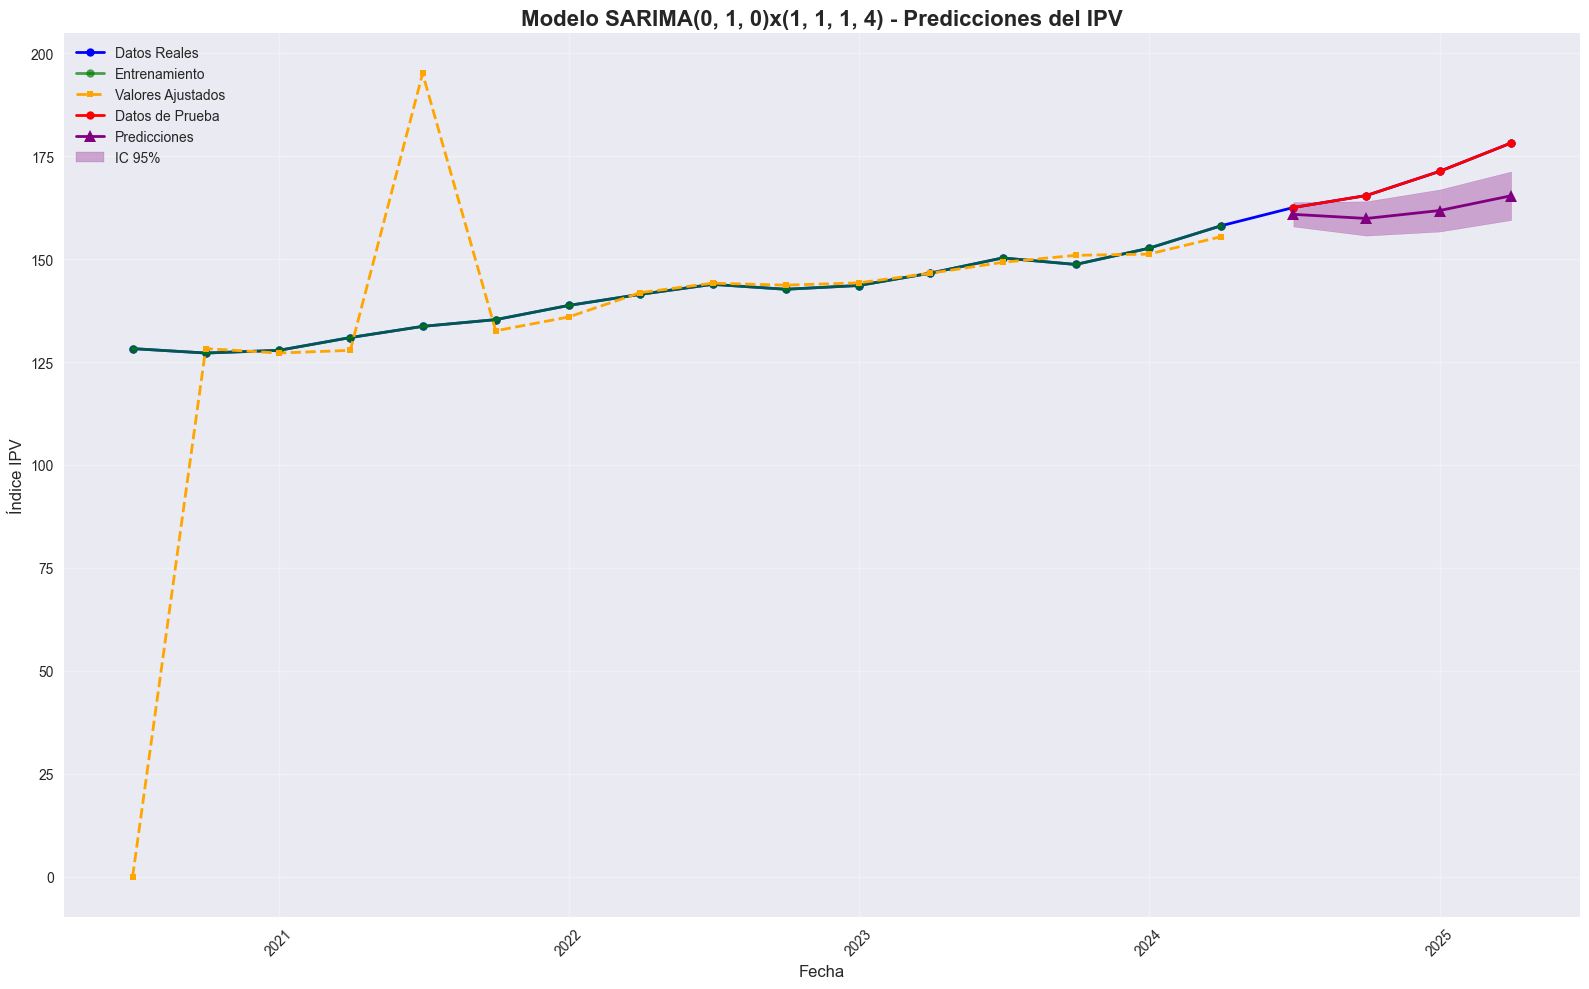


📋 Predicciones detalladas (validación):
   2024T3: 160.859 (IC 95%: [157.917, 163.800])
   2024T4: 159.861 (IC 95%: [155.702, 164.021])
   2025T1: 161.784 (IC 95%: [156.690, 166.879])
   2025T2: 165.372 (IC 95%: [159.490, 171.254])

💾 Predicciones guardadas: 4 registros


In [11]:
# Realizar predicciones y forecasting (adaptativo según modelo y frecuencia)
print("🔮 Realizando predicciones y forecasting...")

# Predicciones in-sample (sobre datos de entrenamiento)
fitted_values = fitted_model.fittedvalues

# Configurar número de períodos a predecir según frecuencia
if frequency == 'anual':
    forecast_periods = 3  # 3 años hacia adelante
    period_name = "años"
elif frequency == 'trimestral':
    forecast_periods = 8  # 8 trimestres (2 años) hacia adelante
    period_name = "trimestres"

# Predicciones out-of-sample
if len(ts_test) > 0:
    forecast_steps = len(ts_test)
    forecast = fitted_model.forecast(steps=forecast_steps)
    forecast_ci = fitted_model.get_forecast(steps=forecast_steps).conf_int()
    forecast_index = ts_test.index
    forecast_type = "validación"
else:
    # Si no hay datos de prueba, hacer forecast hacia el futuro
    forecast_steps = forecast_periods
    forecast = fitted_model.forecast(steps=forecast_steps)
    forecast_ci = fitted_model.get_forecast(steps=forecast_steps).conf_int()
    
    # Crear índices para las predicciones futuras según frecuencia
    last_date = ts_analysis.index[-1]
    
    if frequency == 'anual':
        # Predicciones anuales
        future_dates = [pd.Timestamp(year=last_date.year + i + 1, month=1, day=1) for i in range(forecast_steps)]
    elif frequency == 'trimestral':
        # Predicciones trimestrales
        future_dates = []
        current_date = last_date
        for i in range(forecast_steps):
            if current_date.month == 1:
                next_date = pd.Timestamp(year=current_date.year, month=4, day=1)
            elif current_date.month == 4:
                next_date = pd.Timestamp(year=current_date.year, month=7, day=1)
            elif current_date.month == 7:
                next_date = pd.Timestamp(year=current_date.year, month=10, day=1)
            elif current_date.month == 10:
                next_date = pd.Timestamp(year=current_date.year + 1, month=1, day=1)
            future_dates.append(next_date)
            current_date = next_date
    
    forecast_index = future_dates
    forecast_type = "futuro"

print(f"📊 Predicciones realizadas: {len(forecast)} períodos ({forecast_type})")

# Visualización de resultados
fig, ax = plt.subplots(figsize=(16, 10))

# Serie original completa
ax.plot(ts_analysis.index, ts_analysis.values, 'o-', label='Datos Reales', linewidth=2, markersize=6, color='blue')

# Datos de entrenamiento
ax.plot(ts_train.index, ts_train.values, 'o-', label='Entrenamiento', linewidth=2, markersize=6, color='green', alpha=0.7)

# Valores ajustados (fitted)
ax.plot(ts_train.index, fitted_values, 's--', label='Valores Ajustados', linewidth=2, markersize=4, color='orange')

# Datos de prueba si existen
if len(ts_test) > 0:
    ax.plot(ts_test.index, ts_test.values, 'o-', label='Datos de Prueba', linewidth=2, markersize=6, color='red')

# Predicciones
ax.plot(forecast_index, forecast, '^-', label='Predicciones', linewidth=2, markersize=8, color='purple')

# Intervalos de confianza
ax.fill_between(forecast_index, 
                forecast_ci.iloc[:, 0], 
                forecast_ci.iloc[:, 1], 
                alpha=0.3, color='purple', label='IC 95%')

ax.set_title(f'Modelo {model_name} - Predicciones del {data_type}', fontsize=16, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel(f'Índice {data_type}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mostrar predicciones numéricas
print(f"\n📋 Predicciones detalladas ({forecast_type}):")
for i, (date, pred) in enumerate(zip(forecast_index, forecast)):
    lower_ci = forecast_ci.iloc[i, 0]
    upper_ci = forecast_ci.iloc[i, 1]
    
    if frequency == 'anual':
        date_str = str(date.year)
    elif frequency == 'trimestral':
        quarter = (date.month - 1) // 3 + 1
        date_str = f"{date.year}T{quarter}"
    
    print(f"   {date_str}: {pred:.3f} (IC 95%: [{lower_ci:.3f}, {upper_ci:.3f}])")

# Guardar predicciones para uso posterior
forecast_results = pd.DataFrame({
    'date': forecast_index,
    'forecast': forecast,
    'lower_ci': forecast_ci.iloc[:, 0],
    'upper_ci': forecast_ci.iloc[:, 1]
})

if frequency == 'anual':
    forecast_results['period'] = [d.year for d in forecast_index]
elif frequency == 'trimestral':
    forecast_results['period'] = [f"{d.year}T{(d.month-1)//3+1}" for d in forecast_index]

print(f"\n💾 Predicciones guardadas: {len(forecast_results)} registros")


## 8. Evaluación del Modelo y Preparación para Modelo Híbrido


In [ ]:
# Evaluación del modelo y métricas de rendimiento
print(f"📊 Evaluación del modelo {model_name}...")

# Métricas de ajuste
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Errores in-sample (entrenamiento)
try:
    mae_train = mean_absolute_error(ts_train, fitted_values)
    mse_train = mean_squared_error(ts_train, fitted_values)
    rmse_train = np.sqrt(mse_train)
    mape_train = mean_absolute_percentage_error(ts_train, fitted_values) * 100
    
    print(f"\n📈 Métricas del modelo en conjunto de entrenamiento:")
    print(f"   AIC: {fitted_model.aic:.2f}")
    print(f"   BIC: {fitted_model.bic:.2f}")
    print(f"   MAE: {mae_train:.4f}")
    print(f"   RMSE: {rmse_train:.4f}")
    print(f"   MAPE: {mape_train:.2f}%")
    
    # Si hay conjunto de prueba, evaluar también en él
    if len(ts_test) > 0 and 'forecast' in locals():
        mae_test = mean_absolute_error(ts_test, forecast)
        mse_test = mean_squared_error(ts_test, forecast)
        rmse_test = np.sqrt(mse_test)
        mape_test = mean_absolute_percentage_error(ts_test, forecast) * 100
        
        print(f"\n📊 Métricas en conjunto de prueba:")
        print(f"   MAE: {mae_test:.4f}")
        print(f"   RMSE: {rmse_test:.4f}")
        print(f"   MAPE: {mape_test:.2f}%")
        
except Exception as e:
    print(f"   ⚠️ Error al calcular métricas: {str(e)[:100]}")
    mae_train = mse_train = rmse_train = mape_train = 0

# Información del modelo para documentación
model_summary = {
    'Tipo de modelo': model_type_final if 'model_type_final' in locals() else 'ARIMA/SARIMA',
    'Orden': str(best_order),
    'Orden estacional': str(best_seasonal_order) if best_seasonal_order else 'N/A',
    'Tipo de datos': f"{data_type} ({frequency})",
    'Período de entrenamiento': f"{ts_train.index[0].strftime('%Y-%m')} - {ts_train.index[-1].strftime('%Y-%m')}",
    'Observaciones': len(ts_analysis),
    'AIC': f"{fitted_model.aic:.2f}" if hasattr(fitted_model, 'aic') else 'N/A',
    'RMSE (train)': f"{rmse_train:.4f}" if rmse_train > 0 else 'N/A',
    'MAPE (train)': f"{mape_train:.2f}%" if mape_train > 0 else 'N/A'
}

print(f"\n📋 Resumen del Modelo:")
for key, value in model_summary.items():
    print(f"   {key}: {value}")

print(f"\n✅ Evaluación completada - El modelo está listo para predicciones")


📊 Evaluación del modelo ARIMA...

📈 Métricas del modelo:


NameError: name 'fitted_arima' is not defined

## 9. Conclusiones y Próximos Pasos


In [ ]:
# Conclusiones del análisis (adaptativo según tipo de datos)
print(f"📝 CONCLUSIONES DEL ANÁLISIS DE SERIES TEMPORALES {data_type}")
print("=" * 70)

print(f"\n🎯 MODELO SELECCIONADO:")
model_name_display = model_name if 'model_name' in locals() else 'Modelo no definido'
print(f"   Tipo: {model_name_display}")
print(f"   Datos: {data_type} ({frequency})")

if 'ts_analysis' in locals() and len(ts_analysis) > 0:
    print(f"   Período de análisis: {ts_analysis.index.min().strftime('%Y-%m')} - {ts_analysis.index.max().strftime('%Y-%m')}")
    print(f"   Observaciones: {len(ts_analysis)}")

print(f"\n📊 RENDIMIENTO DEL MODELO:")
if 'fitted_model' in locals():
    try:
        print(f"   AIC: {fitted_model.aic:.2f}")
    except:
        print("   AIC: No disponible")
    
    # Calcular métricas si es posible
    try:
        from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
        
        if hasattr(fitted_model, 'fittedvalues') and 'ts_train' in locals():
            fitted_values = fitted_model.fittedvalues if hasattr(fitted_model.fittedvalues, '__iter__') else fitted_model.fittedvalues()
            if len(fitted_values) == len(ts_train):
                mae_train = mean_absolute_error(ts_train, fitted_values)
                rmse_train = np.sqrt(mean_squared_error(ts_train, fitted_values))
                mape_train = mean_absolute_percentage_error(ts_train, fitted_values) * 100
                print(f"   RMSE Entrenamiento: {rmse_train:.4f}")
                print(f"   MAPE Entrenamiento: {mape_train:.2f}%")
            else:
                print("   Métricas: No disponibles (dimensiones no coinciden)")
        else:
            print("   Métricas: No disponibles")
    except Exception as e:
        print(f"   Métricas: Error al calcular ({str(e)[:30]}...)")
else:
    print("   Modelo no disponible para evaluación")

print(f"\n📈 CARACTERÍSTICAS DE LA SERIE:")
if 'ts_analysis' in locals() and len(ts_analysis) > 1:
    trend_direction = 'Creciente' if ts_analysis.iloc[-1] > ts_analysis.iloc[0] else 'Decreciente'
    print(f"   Tendencia: {trend_direction}")
    
    total_change_pct = ((ts_analysis.iloc[-1] / ts_analysis.iloc[0]) - 1) * 100
    print(f"   Cambio total: {total_change_pct:.1f}%")
    
    if frequency == 'anual':
        years_span = len(ts_analysis)
        if years_span > 1:
            annual_change = (((ts_analysis.iloc[-1] / ts_analysis.iloc[0]) ** (1/years_span)) - 1) * 100
            print(f"   Cambio anual promedio: {annual_change:.1f}%")
    elif frequency == 'trimestral':
        quarters_span = len(ts_analysis)
        if quarters_span > 1:
            quarterly_change = (((ts_analysis.iloc[-1] / ts_analysis.iloc[0]) ** (1/quarters_span)) - 1) * 100
            annual_equivalent = ((1 + quarterly_change/100) ** 4 - 1) * 100
            print(f"   Cambio trimestral promedio: {quarterly_change:.2f}%")
            print(f"   Equivalente anual: {annual_equivalent:.1f}%")
    
    cv = (ts_analysis.std() / ts_analysis.mean()) * 100
    print(f"   Volatilidad (CV): {cv:.1f}%")
else:
    print("   Características no disponibles (datos insuficientes)")

print(f"\n🔮 PREDICCIONES:")
if 'forecast_results' in locals() and len(forecast_results) > 0:
    forecast_type_display = forecast_type if 'forecast_type' in locals() else 'futuro'
    print(f"   Tipo: {forecast_type_display}")
    for i, row in forecast_results.iterrows():
        if i < 5:  # Mostrar solo las primeras 5 predicciones
            period_display = row['period'] if 'period' in row else f"Período {i+1}"
            print(f"   {period_display}: {row['forecast']:.3f} (IC: [{row['lower_ci']:.3f}, {row['upper_ci']:.3f}])")
        elif i == 5:
            remaining = len(forecast_results) - 5
            print(f"   ... y {remaining} predicciones más")
            break
else:
    print("   No hay predicciones disponibles")

print(f"\n🔗 INTEGRACIÓN CON MODELOS ML:")
model_type_display = model_type_final if 'model_type_final' in locals() else 'ARIMA'
print(f"   ✅ Residuos {model_type_display} disponibles como features")
print(f"   ✅ Predicciones {model_type_display} como variables explicativas")
print(f"   ✅ Features temporales creados para ML")
print(f"   ✅ Componentes de tendencia extraídos")
if frequency == 'trimestral':
    print(f"   ✅ Componentes estacionales disponibles")

print(f"\n⚠️ LIMITACIONES Y CONSIDERACIONES:")
obs_count = len(ts_analysis) if 'ts_analysis' in locals() else 0
print(f"   • Serie temporal con {obs_count} observaciones ({frequency})")
if frequency == 'anual':
    print(f"   • Datos anuales limitan análisis estacional")
elif frequency == 'trimestral':
    print(f"   • Datos trimestrales permiten análisis estacional")
print(f"   • Modelo sensible a outliers por tamaño de muestra")
print(f"   • Intervalos de confianza amplios en predicciones")

print(f"\n🚀 RECOMENDACIONES PARA MODELO HÍBRIDO:")
print(f"   1. Usar predicciones {model_type_display} como feature en modelos ML")
print(f"   2. Incorporar residuos {model_type_display} para capturar patrones no lineales")
print(f"   3. Combinar con variables macroeconómicas externas")
if frequency == 'trimestral':
    print(f"   4. Aprovechar componentes estacionales para mejorar predicciones")
    print(f"   5. Considerar ensemble de SARIMA + Random Forest/XGBoost")
else:
    print(f"   4. Considerar ensemble de ARIMA + Random Forest/XGBoost")
print(f"   {'6' if frequency == 'trimestral' else '5'}. Validar con técnicas de series temporales (walk-forward)")

print(f"\n✅ PRÓXIMOS PASOS:")
print(f"   📊 Integrar este análisis en pipeline de ML")
print(f"   🔧 Desarrollar modelo híbrido {model_type_display}+ML")
print(f"   📈 Validar predicciones con datos más recientes")
print(f"   📋 Documentar metodología para reproducibilidad")

print(f"\n🎉 Análisis de series temporales {data_type} completado exitosamente!")
print(f"📁 Notebook compatible con ambos tipos de datos INE (IPVA/IPV)")
print(f"🔧 Modelo {model_name_display} listo para integración con ML")


📝 CONCLUSIONES DEL ANÁLISIS DE SERIES TEMPORALES IPV

🎯 MODELO SELECCIONADO:
   Tipo: SARIMA(0, 1, 0)x(1, 1, 1, 4)
   Datos: IPV (trimestral)
   Período de análisis: 2020-07 - 2025-04
   Observaciones: 20

📊 RENDIMIENTO DEL MODELO:
   AIC: 48.68
   RMSE Entrenamiento: 35.5879
   MAPE Entrenamiento: 10.01%

📈 CARACTERÍSTICAS DE LA SERIE:
   Tendencia: Creciente
   Cambio total: 38.9%
   Cambio trimestral promedio: 1.66%
   Equivalente anual: 6.8%
   Volatilidad (CV): 10.1%

🔮 PREDICCIONES (validación):


TypeError: '<' not supported between instances of 'Timestamp' and 'int'